In [ ]:
#stride - to take subset from matrix of image then match with the original matrix
#padding - remove outer layer of image matrix

#redix sort

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print(f"We have {len(X_train)} images in the training set and {len(X_test)} images in the test set.")
print(f"The size of the images is {X_train[0].shape}.")

We have 60000 images in the training set and 10000 images in the test set.
The size of the images is (28, 28).


In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
import matplotlib.pyplot as plt


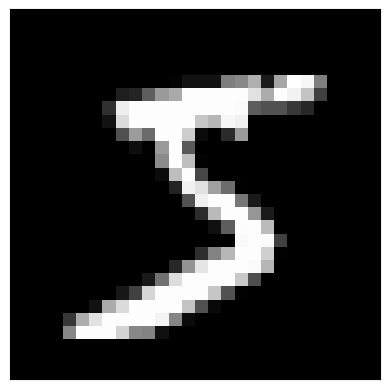

pixel values:
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0

In [ ]:
plt.imshow(X_train[0], cmap="grey")
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()

print("pixel values:")
for row in X_train[0]:
   for pixel in row:
    print("{:3}".format(pixel), end="")
   print()

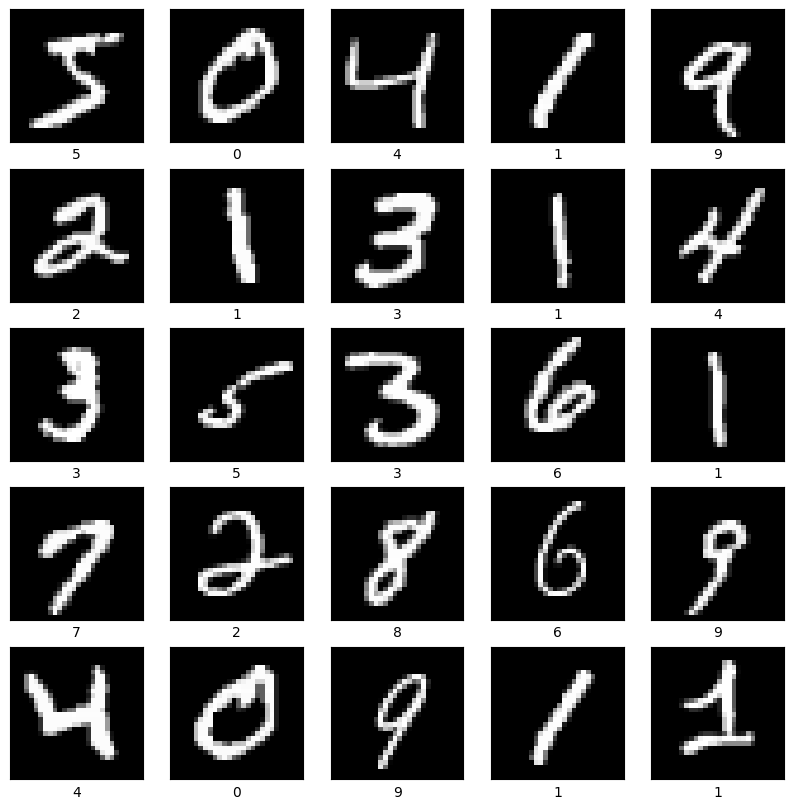

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i], cmap="grey")
  plt.xlabel(y_train[i])
plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
input_layer = tf.keras.layers.Input(shape=(28, 28, 1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
model = tf.keras.Sequential([
    input_layer,
    layers.Conv2D(filters=10, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

In [ ]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1690)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,010 (66.45 KB)

 Trainable params: 17,010 (66.45 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=64)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.8932 - loss: 0.4055 - val_accuracy: 0.9446 - val_loss: 0.2010
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9519 - loss: 0.1665 - val_accuracy: 0.9632 - val_loss: 0.1367
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9668 - loss: 0.1177 - val_accuracy: 0.9700 - val_loss: 0.1076


In [ ]:
loss, accuracy, = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9701 - loss: 0.1020
Test accuracy: 97.01


In [ ]:
import joblib # for load model once it's been made

In [ ]:
joblib.dump(model, "cnn_mnist_model.keras") # to avoide above code

['cnn_mnist_model.keras']

In [ ]:
loaded_model = joblib.load("cnn_mnist_model.pkl")

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import RMSprop

In [ ]:
model = joblib.load("cnn_mnist_model.pkl")
model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss="categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
model.fit(X_train, y_train, validation_split=0.2, epochs=2, batch_size=64)

Epoch 1/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9724 - loss: 0.0951 - val_accuracy: 0.9747 - val_loss: 0.0928
Epoch 2/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9764 - loss: 0.0830 - val_accuracy: 0.9758 - val_loss: 0.0877


In [ ]:
loass, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9762 - loss: 0.0780
Test accuracy: 97.62
